In [12]:
import pandas as pd
import numpy as np

ruta = "../data/tcga_simple_train.csv"
df = pd.read_csv(ruta)

df.head

<bound method NDFrame.head of         patient_id                                               text   t
0     TCGA-BP-5195  Date of Recelpt: Clinical Diagnosis & History:...  T1
1     TCGA-D7-8573  Material: 1) Material: stomach, Method of coll...  T3
2     TCGA-EI-7004  page 1 / 1. copy No. 3. Examination: Histopath...  T4
3     TCGA-EB-A82B  Patient ID: Gross Description: A mass is locat...  T4
4     TCGA-A6-3808  SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...  T3
...            ...                                                ...  ..
5153  TCGA-GM-A3XL  DIAGNOSIS. (A) RIGHT AXILLARY SENTINEL LYMPH N...  T2
5154  TCGA-DJ-A2Q7  Clinical Diagnosis & History: Bilateral thyroi...  T2
5155  TCGA-CK-4948  Type: Surgical Pathology. COLON, SEGMENTAL RES...  T3
5156  TCGA-AA-3538  Diagnosis/Diagnoses: 1.: Excision specimen fro...  T2
5157  TCGA-A8-A08O  Diagnosis: Invasive ductal breast carcinoma (m...  T2

[5158 rows x 3 columns]>

Probabilidad de cada clase (en %):
t
T1    25.242342
T2    33.966654
T3    30.690190
T4    10.100814
Name: proportion, dtype: float64


C:\Users\Jorge\AppData\Local\Temp\ipykernel_8864\1084163757.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='t', order=orden, palette='magma')


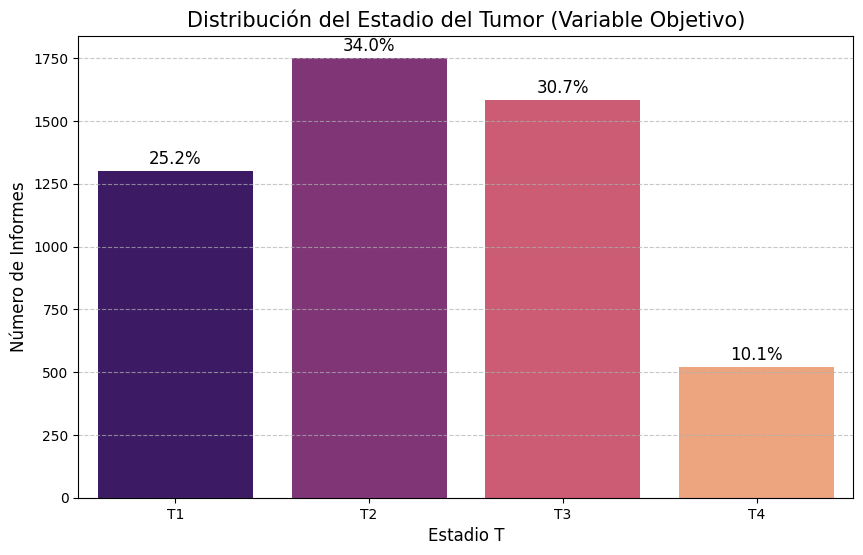

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

distribucion = df['t'].value_counts(normalize=True).sort_index() * 100

print("Probabilidad de cada clase (en %):")
print(distribucion)

plt.figure(figsize=(10, 6))
orden = ['T1', 'T2', 'T3', 'T4']

ax = sns.countplot(data=df, x='t', order=orden, palette='magma')

for p in ax.patches:
    percentage = f'{100 * p.get_height() / len(df):.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribución del Estadio del Tumor (Variable Objetivo)', fontsize=15)
plt.xlabel('Estadio T', fontsize=12)
plt.ylabel('Número de Informes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\Jorge\AppData\Local\Temp\ipykernel_8864\3478399052.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='t', y='word_count', order=orden, palette='viridis')


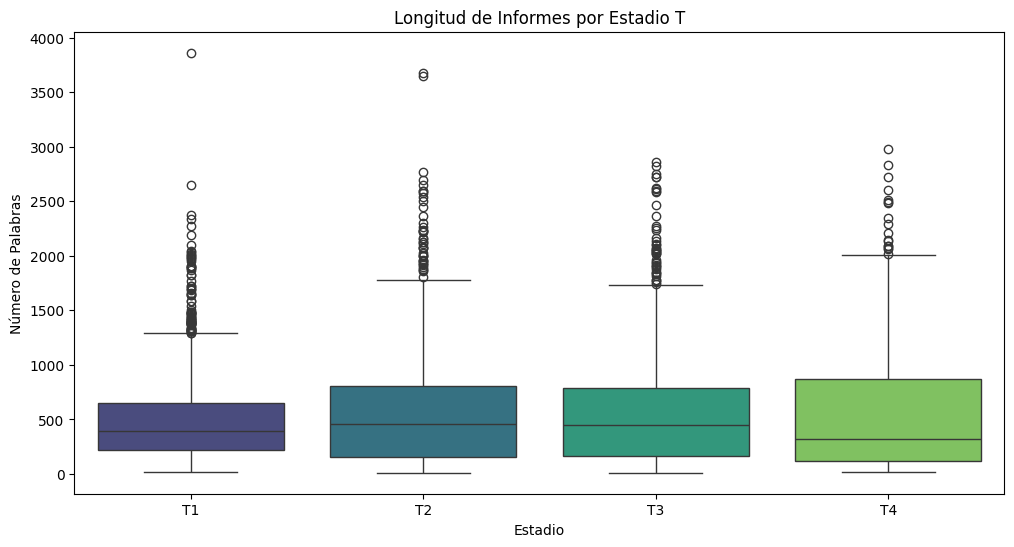

In [13]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='t', y='word_count', order=orden, palette='viridis')
plt.title('Longitud de Informes por Estadio T')
plt.xlabel('Estadio')
plt.ylabel('Número de Palabras')
plt.show()

In [14]:
import re
def count_measures(text):
    return len(re.findall(r'\d+(?:\.\d+)?\s*(?:cm|mm)', str(text).lower()))

df['measure_count'] = df['text'].apply(count_measures)
print(df.groupby('t')['measure_count'].mean())

t
T1     9.107527
T2    10.296233
T3    10.638661
T4    10.660269
Name: measure_count, dtype: float64


In [19]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]


top_bigrams_t1 = get_top_ngram(df[df['t']=='T1']['text'], n=2)
top_bigrams_t2 = get_top_ngram(df[df['t']=='T2']['text'], n=2)
top_bigrams_t3 = get_top_ngram(df[df['t']=='T3']['text'], n=2)
top_bigrams_t4 = get_top_ngram(df[df['t']=='T4']['text'], n=2)

print("Top 10 bigramas para T1:", top_bigrams_t1)
print("Top 10 bigramas para T2:", top_bigrams_t2)
print("Top 10 bigramas para T3:", top_bigrams_t3)
print("Top 10 bigramas para T4:", top_bigrams_t4)

Top 10 bigramas para T1: [('lymph node', np.int64(5105)), ('lymph nodes', np.int64(4072)), ('measuring cm', np.int64(1512)), ('frozen section', np.int64(1369)), ('cell carcinoma', np.int64(1206)), ('received fresh', np.int64(1074)), ('greatest dimension', np.int64(1038)), ('soft tissue', np.int64(878)), ('entirely submitted', np.int64(876)), ('measures cm', np.int64(871))]
Top 10 bigramas para T2: [('lymph node', np.int64(8874)), ('lymph nodes', np.int64(8184)), ('measuring cm', np.int64(2356)), ('frozen section', np.int64(2342)), ('received fresh', np.int64(1790)), ('soft tissue', np.int64(1436)), ('greatest dimension', np.int64(1398)), ('specimen received', np.int64(1283)), ('gross description', np.int64(1182)), ('entirely submitted', np.int64(1167))]
Top 10 bigramas para T3: [('lymph nodes', np.int64(9355)), ('lymph node', np.int64(6743)), ('frozen section', np.int64(2077)), ('measuring cm', np.int64(1969)), ('soft tissue', np.int64(1759)), ('specimen received', np.int64(1536)), ('r